# Differential Amino Acid Classification

This notebook demonstrates how to train and use the `DifferentialSpectralClassifier` to identify which amino acid was removed when comparing an n-amino acid peptide spectrum to an (n-1)-amino acid peptide spectrum.

## Use Case

Given:
- Spectrum of an n-amino acid mixture (S_n)
- Spectrum of (n-1)-amino acid mixture (S_{n-1})

Task: Identify which amino acid was removed

Under the linear superposition model: `S_n - S_{n-1} ≈ α × S_removed`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

## 1. Load Amino Acid Fingerprints

First, we load the reference fingerprint spectra for each amino acid. These are used to generate synthetic training data.

In [2]:
from spectra.models import load_amino_acid_fingerprints

# Load fingerprints from monopeptide data
data_root = Path('data/monopeptide')
fingerprints = load_amino_acid_fingerprints(data_root)

print(f"Loaded fingerprints for {len(fingerprints)} amino acids:")
for aa_name in sorted(fingerprints.keys()):
    print(f"  - {aa_name}: {len(fingerprints[aa_name])} points")

Loaded fingerprints for 19 amino acids:
  - alanine: 1023 points
  - arginine: 1023 points
  - asparagine: 1023 points
  - aspartic acid: 1023 points
  - cysteine: 1023 points
  - glutamic acid: 1023 points
  - glutamine: 1023 points
  - glycine: 1023 points
  - isoleucine: 1023 points
  - leucine: 1023 points
  - lysine: 1023 points
  - methionine: 1023 points
  - phenylalanine: 1023 points
  - proline: 1023 points
  - serine: 1023 points
  - threonine: 1023 points
  - tryptophan: 1023 points
  - tyrosine: 1023 points
  - valine: 1023 points


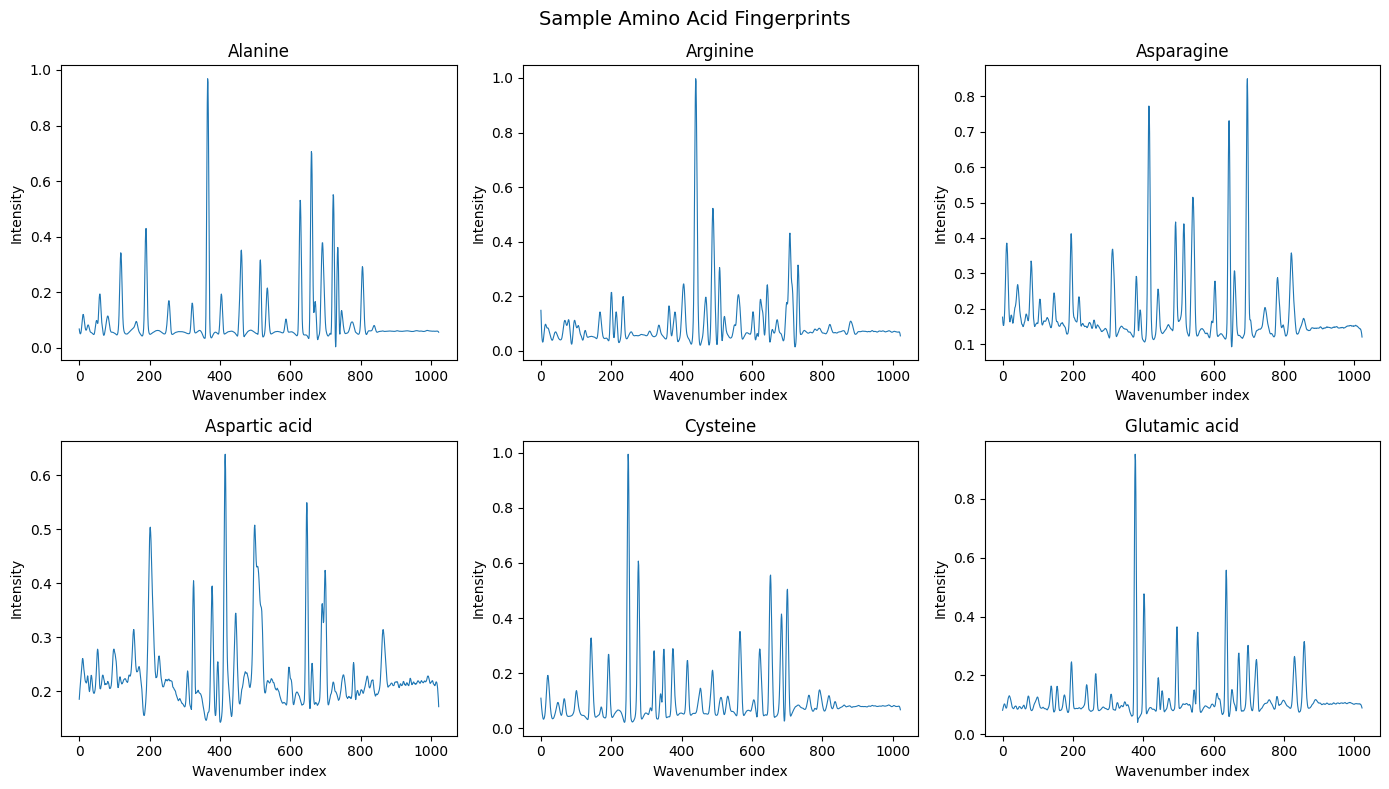

In [3]:
# Visualize a few fingerprints
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_aas = list(fingerprints.keys())[:6]
for ax, aa_name in zip(axes, sample_aas):
    spectrum = fingerprints[aa_name]
    ax.plot(spectrum, linewidth=0.8)
    ax.set_title(aa_name.capitalize())
    ax.set_xlabel('Wavenumber index')
    ax.set_ylabel('Intensity')

plt.suptitle('Sample Amino Acid Fingerprints', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Create Training Dataset

The `DifferentialPairDataset` generates synthetic pairs (S_n, S_{n-1}) where we know which amino acid was removed.

In [7]:
from spectra.models import DifferentialPairDataset

# Create training dataset
train_dataset = DifferentialPairDataset(
    fingerprints,
    n_samples=30000,            # Number of training pairs
    peptide_length_range=(2, 5), # n ranges from 3 to 8
    noise_level=0.02,           # Gaussian noise std
    intensity_variation=0.1,     # ±10% intensity scaling
    seed=42,
)

# Create validation dataset with different seed
val_dataset = DifferentialPairDataset(
    fingerprints,
    n_samples=6000,
    peptide_length_range=(2, 5),
    noise_level=0.02,
    intensity_variation=0.1,
    seed=123,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {train_dataset.num_classes}")

Training samples: 30000
Validation samples: 6000
Number of classes: 19


In [8]:
# Check class distribution
label_names = train_dataset.get_label_names()
print(f"\nAmino acids in dataset ({len(label_names)}):")
for i, name in enumerate(label_names):
    print(f"  {i}: {name}")


Amino acids in dataset (19):
  0: alanine
  1: arginine
  2: asparagine
  3: aspartic acid
  4: cysteine
  5: glutamic acid
  6: glutamine
  7: glycine
  8: isoleucine
  9: leucine
  10: lysine
  11: methionine
  12: phenylalanine
  13: proline
  14: serine
  15: threonine
  16: tryptophan
  17: tyrosine
  18: valine


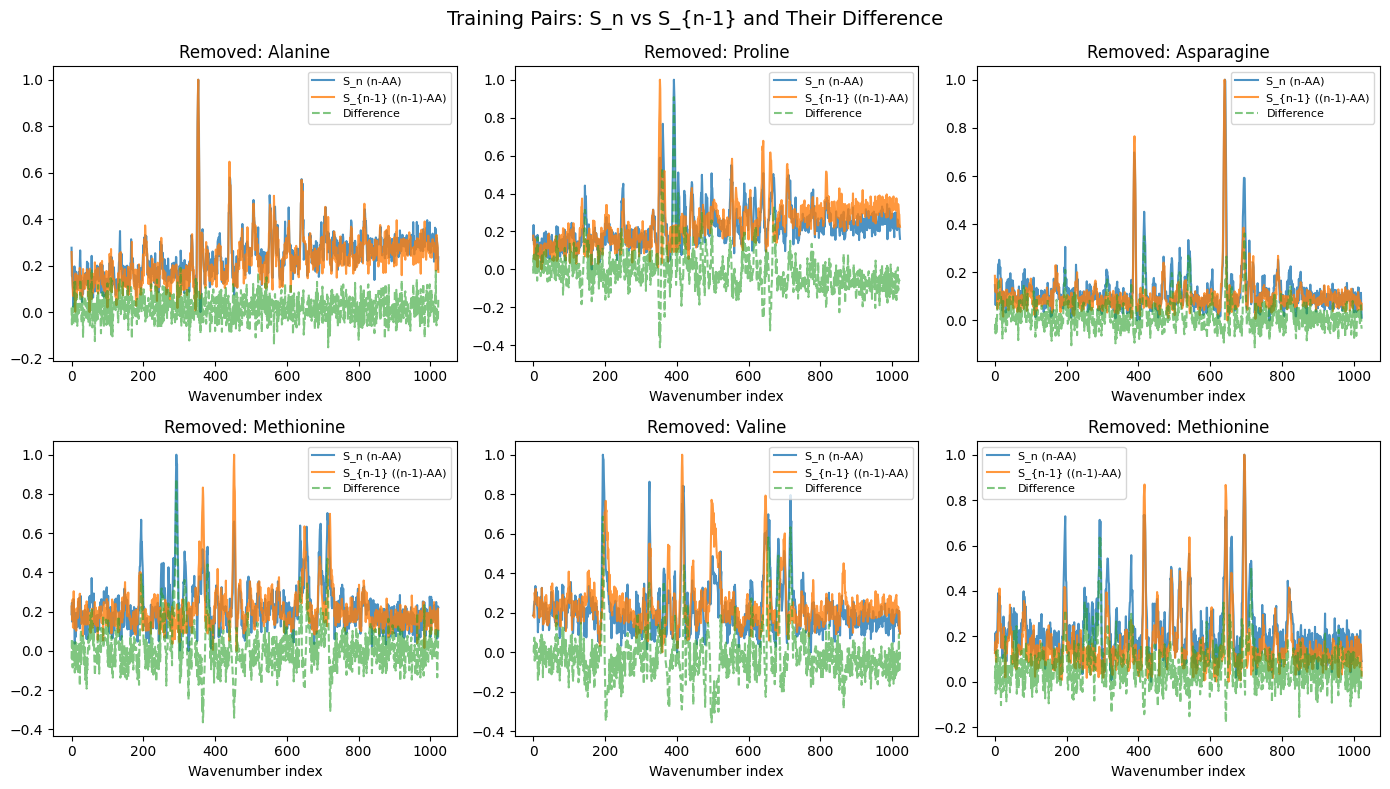

In [6]:
# Visualize some training pairs
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, ax in enumerate(axes.flatten()):
    s_n, s_n1, label = train_dataset[idx]
    removed_aa = label_names[label.item()]
    
    ax.plot(s_n.numpy(), label='S_n (n-AA)', alpha=0.8)
    ax.plot(s_n1.numpy(), label='S_{n-1} ((n-1)-AA)', alpha=0.8)
    ax.plot(s_n.numpy() - s_n1.numpy(), label='Difference', alpha=0.6, linestyle='--')
    ax.set_title(f'Removed: {removed_aa.capitalize()}')
    ax.legend(fontsize=8)
    ax.set_xlabel('Wavenumber index')

plt.suptitle('Training Pairs: S_n vs S_{n-1} and Their Difference', fontsize=14)
plt.tight_layout()
plt.show()

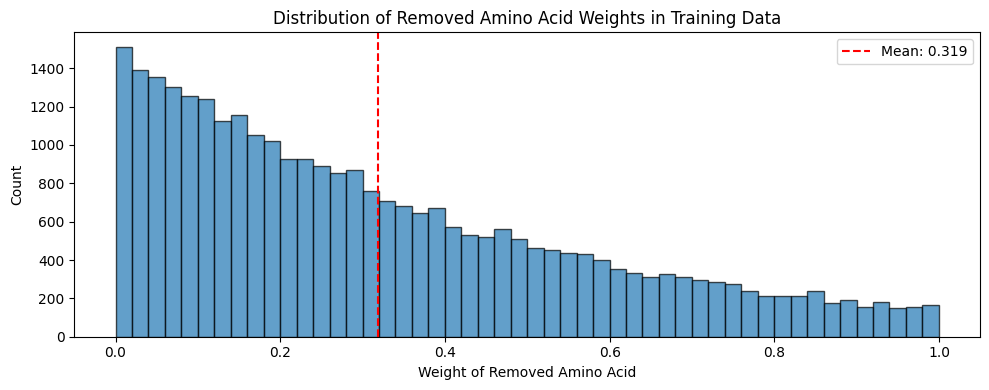

Removal weight stats:
  Mean: 0.319
  Std:  0.252
  Min:  0.000
  Max:  1.000


In [9]:
# Analyze the removal weight distribution
removal_weights = train_dataset.get_removal_weight_distribution()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(removal_weights, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Weight of Removed Amino Acid')
ax.set_ylabel('Count')
ax.set_title('Distribution of Removed Amino Acid Weights in Training Data')
ax.axvline(removal_weights.mean(), color='red', linestyle='--', label=f'Mean: {removal_weights.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Removal weight stats:")
print(f"  Mean: {removal_weights.mean():.3f}")
print(f"  Std:  {removal_weights.std():.3f}")
print(f"  Min:  {removal_weights.min():.3f}")
print(f"  Max:  {removal_weights.max():.3f}")

## 3. Create the Model

The `DifferentialSpectralClassifier` uses a dual-path architecture:
1. Shared CNN encoder processes both spectra
2. Embedding difference captures what's unique to S_n
3. Optional raw spectral difference pathway
4. Transformer encoder processes differential features
5. Classification head predicts the removed amino acid

In [10]:
from spectra.models import DifferentialSpectralClassifier, DifferentialModelConfig

# Configure the model
model_config = DifferentialModelConfig(
    d_model=128,                 # Embedding dimension
    nhead=8,                     # Attention heads
    num_encoder_layers=2,        # Transformer layers
    dim_feedforward=256,         # FFN hidden dimension
    dropout=0.3,                 # Dropout rate
    num_classes=train_dataset.num_classes,
    use_raw_difference=True,     # Include raw spectral difference path
    use_cross_attention=False,   # Start simple, can enable later
)

# Create model
model = DifferentialSpectralClassifier(model_config)

print(f"Model created with {model.count_parameters():,} trainable parameters")
print(f"\nConfiguration:")
for key, value in model_config.to_dict().items():
    print(f"  {key}: {value}")

Model created with 464,403 trainable parameters

Configuration:
  seq_length: 1023
  d_model: 128
  nhead: 8
  num_encoder_layers: 2
  dim_feedforward: 256
  dropout: 0.3
  num_classes: 19
  activation: gelu
  norm_first: True
  use_raw_difference: True
  use_cross_attention: False
  num_cross_attention_heads: 4
  fusion_method: concat
  pretrained_checkpoint: None
  freeze_pretrained: False


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
# Test forward pass
import torch

s_n, s_n1, label = train_dataset[0]
s_n_batch = s_n.unsqueeze(0)  # Add batch dimension
s_n1_batch = s_n1.unsqueeze(0)

model.eval()
with torch.no_grad():
    output = model(s_n_batch, s_n1_batch)
    probs = torch.softmax(output, dim=1)
    pred = output.argmax(dim=1).item()

print(f"Input shapes: S_n={s_n_batch.shape}, S_{{n-1}}={s_n1_batch.shape}")
print(f"Output shape: {output.shape}")
print(f"True label: {label.item()} ({label_names[label.item()]})")
print(f"Predicted: {pred} ({label_names[pred]})")
print(f"Top prediction confidence: {probs[0, pred].item():.2%}")

Input shapes: S_n=torch.Size([1, 1023]), S_{n-1}=torch.Size([1, 1023])
Output shape: torch.Size([1, 19])
True label: 0 (alanine)
Predicted: 11 (methionine)
Top prediction confidence: 10.41%


## 4. Train the Model

In [12]:
from spectra.models import DifferentialTrainer, TrainingConfig

# Configure training
training_config = TrainingConfig(
    learning_rate=0.001,
    batch_size=64,
    epochs=50,                    # Adjust based on your needs
    early_stopping_patience=10,
    lr_scheduler='reduce_on_plateau',
    lr_patience=5,
    lr_factor=0.5,
    checkpoint_dir='checkpoints/differential',
    seed=42,
)

# Get class weights for handling imbalance
class_weights = train_dataset.get_class_weights()

# Create trainer
trainer = DifferentialTrainer(
    model=model,
    config=training_config,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    class_weights=class_weights,
)

In [13]:
# Train the model
history = trainer.train(verbose=True)

Training DifferentialSpectralClassifier on cuda
Train samples: 30000
Val samples: 6000
Model parameters: 464,403
------------------------------------------------------------
Epoch   1/50 | Train Loss: 2.6625, Acc:  16.59% | Val Loss: 2.6922, Acc:  24.97% | LR: 1.00e-03
Epoch   2/50 | Train Loss: 1.5733, Acc:  63.54% | Val Loss: 1.2810, Acc:  76.87% | LR: 1.00e-03
Epoch   3/50 | Train Loss: 1.0361, Acc:  86.89% | Val Loss: 0.9787, Acc:  88.75% | LR: 1.00e-03
Epoch   4/50 | Train Loss: 0.9403, Acc:  89.81% | Val Loss: 0.9288, Acc:  90.22% | LR: 1.00e-03
Epoch   5/50 | Train Loss: 0.8999, Acc:  90.80% | Val Loss: 0.8999, Acc:  90.83% | LR: 1.00e-03
Epoch   6/50 | Train Loss: 0.8767, Acc:  91.29% | Val Loss: 0.8822, Acc:  91.05% | LR: 1.00e-03
Epoch   7/50 | Train Loss: 0.8639, Acc:  91.66% | Val Loss: 0.8571, Acc:  91.55% | LR: 1.00e-03
Epoch   8/50 | Train Loss: 0.8500, Acc:  92.09% | Val Loss: 0.8624, Acc:  91.58% | LR: 1.00e-03
Epoch   9/50 | Train Loss: 0.8414, Acc:  92.34% | Val Loss

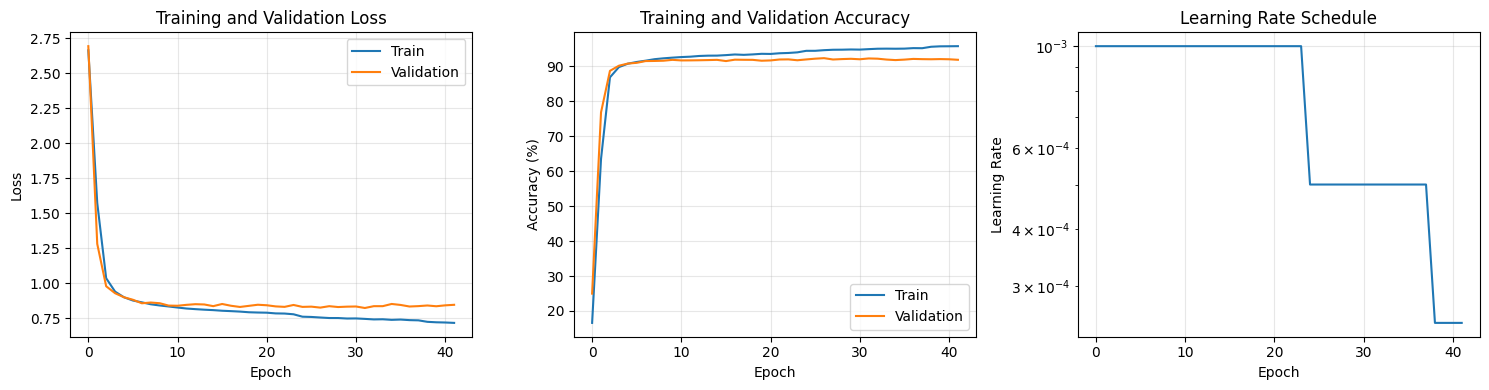


Best validation accuracy: 92.38%
Best validation loss: 0.8235


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest validation accuracy: {max(history['val_acc']):.2f}%")
print(f"Best validation loss: {min(history['val_loss']):.4f}")

## 5. Evaluate the Model

In [15]:
from spectra.models import DifferentialPredictor
from spectra.models import confusion_matrix, classification_report

# Create predictor
predictor = DifferentialPredictor(model)

# Evaluate on validation set
all_preds = []
all_labels = []

for i in range(len(val_dataset)):
    s_n, s_n1, label = val_dataset[i]
    pred = predictor.predict(s_n.numpy(), s_n1.numpy())
    all_preds.append(pred[0])
    all_labels.append(label.item())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean() * 100
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 92.30%


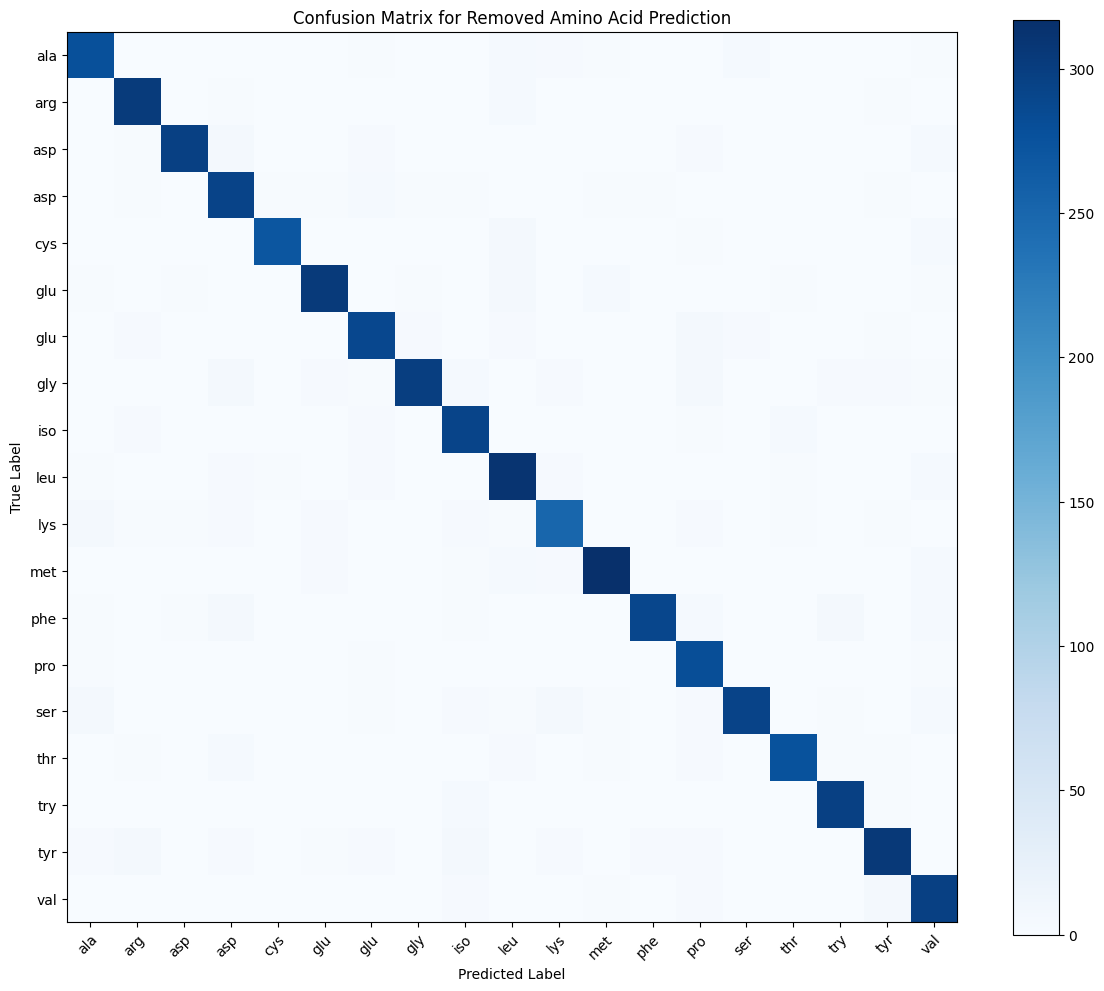

In [16]:
# Confusion matrix
cm = confusion_matrix(all_preds, all_labels)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Labels
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=[n[:3] for n in label_names],
       yticklabels=[n[:3] for n in label_names],
       ylabel='True Label',
       xlabel='Predicted Label')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax.set_title('Confusion Matrix for Removed Amino Acid Prediction')

plt.tight_layout()
plt.show()

In [20]:
# Classification report
report = classification_report(all_preds, all_labels, label_names)

print("Per-class Performance:")
print("-" * 60)
print(f"{'Amino Acid':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for name in label_names:
    if name in report:
        p = report[name]['precision']
        r = report[name]['recall']
        f1 = report[name]['f1']
        print(f"{name:<20} {p:>10.2%} {r:>10.2%} {f1:>10.2%}")

print("-" * 60)
print(f"{'Macro Average':<20} {report['macro_avg']['precision']:>10.2%} "
      f"{report['macro_avg']['recall']:>10.2%} {report['macro_avg']['f1']:>10.2%}")
print(f"{'Weighted Average':<20} {report['weighted_avg']['precision']:>10.2%} "
      f"{report['weighted_avg']['recall']:>10.2%} {report['weighted_avg']['f1']:>10.2%}")

Per-class Performance:
------------------------------------------------------------
Amino Acid            Precision     Recall         F1
------------------------------------------------------------
alanine                  90.85%     93.60%     92.21%
arginine                 91.82%     93.81%     92.80%
asparagine               95.79%     91.64%     93.67%
aspartic acid            88.52%     92.14%     90.29%
cysteine                 96.43%     94.08%     95.24%
glutamic acid            94.12%     91.84%     92.97%
glutamine                90.57%     92.01%     91.28%
glycine                  95.22%     88.99%     92.00%
isoleucine               90.12%     93.59%     91.82%
leucine                  89.63%     93.11%     91.34%
lysine                   90.29%     88.69%     89.48%
methionine               93.51%     93.51%     93.51%
phenylalanine            96.01%     90.88%     93.38%
proline                  86.96%     94.92%     90.76%
serine                   95.75%     89.33%   

## 6. Inference Examples

In [21]:
# Test on some examples
n_examples = 5

print("Sample Predictions:")
print("=" * 70)

for i in range(n_examples):
    s_n, s_n1, label = val_dataset[i]
    true_aa = label_names[label.item()]
    
    # Get prediction
    pred_aa = predictor.predict_amino_acid(s_n.numpy(), s_n1.numpy())
    
    # Get top-3 predictions with confidence
    top_k = predictor.predict_top_k(s_n.numpy(), s_n1.numpy(), k=3)
    
    status = "✓" if pred_aa == true_aa else "✗"
    print(f"\nExample {i+1}: {status}")
    print(f"  True: {true_aa}")
    print(f"  Predicted: {pred_aa}")
    print(f"  Top-3 predictions:")
    for name, prob in top_k:
        marker = "←" if name == true_aa else ""
        print(f"    {name}: {prob:.1%} {marker}")

Sample Predictions:

Example 1: ✓
  True: glutamic acid
  Predicted: glutamic acid
  Top-3 predictions:
    glutamic acid: 92.1% ←
    threonine: 0.6% 
    histidine: 0.5% 

Example 2: ✗
  True: leucine
  Predicted: isoleucine
  Top-3 predictions:
    isoleucine: 89.4% 
    pyrrolysine: 0.8% 
    glutamic acid: 0.7% 

Example 3: ✓
  True: cysteine
  Predicted: cysteine
  Top-3 predictions:
    cysteine: 91.2% ←
    pyrrolysine: 0.6% 
    leucine: 0.6% 

Example 4: ✓
  True: glutamic acid
  Predicted: glutamic acid
  Top-3 predictions:
    glutamic acid: 91.8% ←
    threonine: 0.6% 
    asparagine: 0.5% 

Example 5: ✗
  True: phenylalanine
  Predicted: methionine
  Top-3 predictions:
    methionine: 58.3% 
    cysteine: 4.3% 
    glutamic acid: 4.2% 


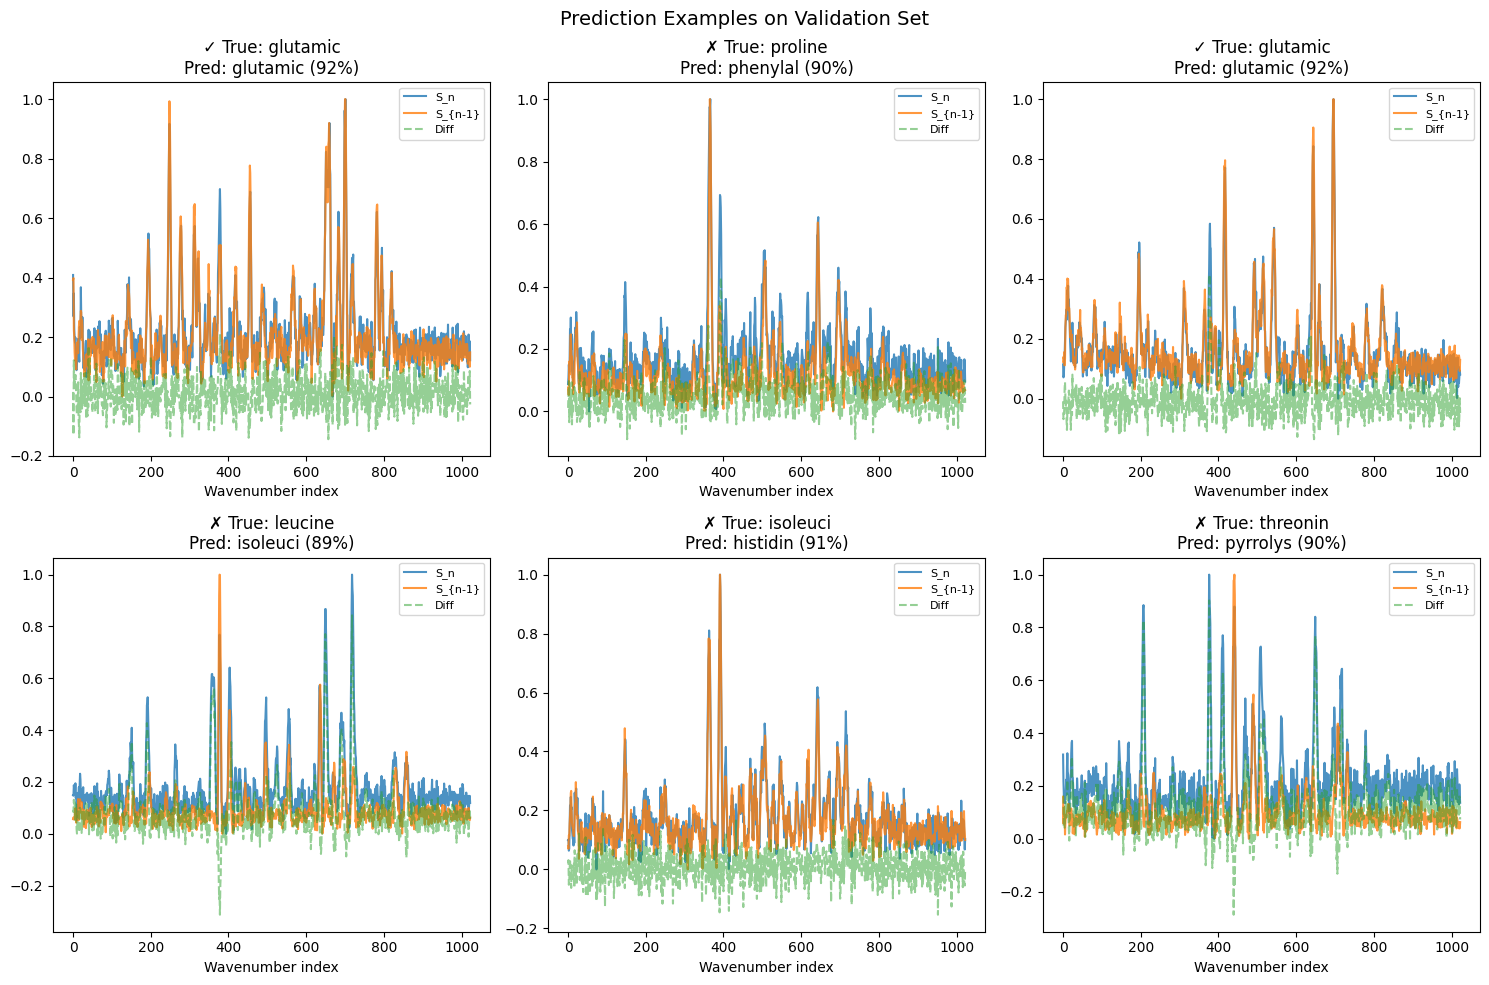

In [22]:
# Visualize predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, ax in enumerate(axes.flatten()):
    s_n, s_n1, label = val_dataset[idx * 100]  # Sample at intervals
    true_aa = label_names[label.item()]
    
    pred_aa = predictor.predict_amino_acid(s_n.numpy(), s_n1.numpy())
    probs = predictor.predict_proba(s_n.numpy(), s_n1.numpy())[0]
    confidence = probs.max()
    
    # Plot spectra
    ax.plot(s_n.numpy(), label='S_n', alpha=0.8)
    ax.plot(s_n1.numpy(), label='S_{n-1}', alpha=0.8)
    ax.plot(s_n.numpy() - s_n1.numpy(), label='Diff', alpha=0.5, linestyle='--')
    
    status = "✓" if pred_aa == true_aa else "✗"
    ax.set_title(f'{status} True: {true_aa[:8]}\nPred: {pred_aa[:8]} ({confidence:.0%})')
    ax.legend(fontsize=8)
    ax.set_xlabel('Wavenumber index')

plt.suptitle('Prediction Examples on Validation Set', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Save and Load Model

In [23]:
# Save the model with label mapping
save_path = 'checkpoints/differential/differential_model_final.pt'
predictor.save(save_path, additional_info={
    'label_names': label_names,
    'training_history': history,
})
print(f"Model saved to: {save_path}")

Model saved to: checkpoints/differential/differential_model_final.pt


In [24]:
# Load the model
loaded_predictor = DifferentialPredictor.load(save_path)

# Verify it works
s_n, s_n1, label = val_dataset[0]
pred = loaded_predictor.predict_amino_acid(s_n.numpy(), s_n1.numpy())
print(f"Loaded model prediction: {pred}")
print(f"True label: {label_names[label.item()]}")

Loaded model prediction: glutamic acid
True label: glutamic acid


C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 8. Analyze Differential Embeddings

Visualize the learned differential representations using t-SNE.

In [26]:
from sklearn.manifold import TSNE

# Extract embeddings for a subset of validation data
n_samples = 1000
embeddings = []
labels = []

for i in range(min(n_samples, len(val_dataset))):
    s_n, s_n1, label = val_dataset[i]
    emb = predictor.get_differential_embeddings(s_n.numpy(), s_n1.numpy())
    embeddings.append(emb[0])
    labels.append(label.item())

embeddings = np.array(embeddings)
labels = np.array(labels)

print(f"Extracted {len(embeddings)} embeddings of shape {embeddings.shape[1]}")

Extracted 1000 embeddings of shape 128


C:\Users\mfarzi\AppData\Local\Temp\ipykernel_7388\311701939.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(label_names))


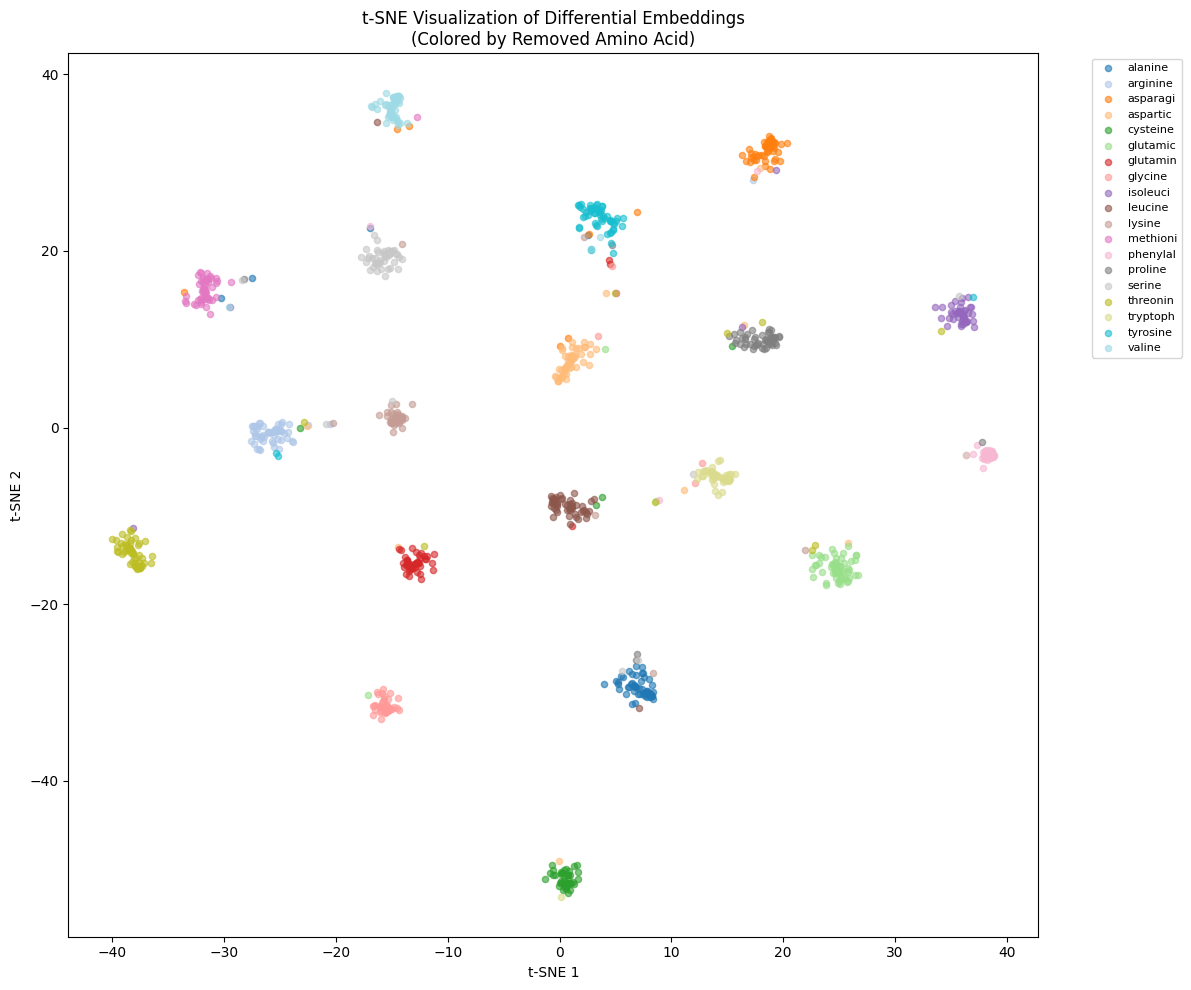

In [27]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

# Use a colormap with enough distinct colors
cmap = plt.cm.get_cmap('tab20', len(label_names))

for i, aa_name in enumerate(label_names):
    mask = labels == i
    if mask.sum() > 0:
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                   label=aa_name[:8], alpha=0.6, s=20, c=[cmap(i)])

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE Visualization of Differential Embeddings\n(Colored by Removed Amino Acid)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Analysis: Effect of Removal Weight

Analyze how the model performs based on the weight of the removed amino acid.

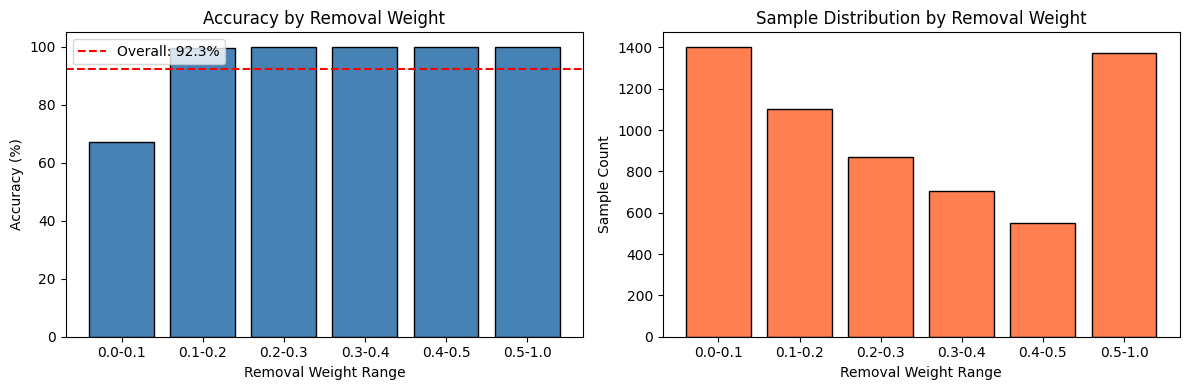


Accuracy by removal weight:
  0.0-0.1: 67.3% (1403 samples)
  0.1-0.2: 99.7% (1100 samples)
  0.2-0.3: 100.0% (870 samples)
  0.3-0.4: 100.0% (704 samples)
  0.4-0.5: 100.0% (548 samples)
  0.5-1.0: 100.0% (1375 samples)


In [28]:
# Analyze accuracy by removal weight
weights = val_dataset.get_removal_weight_distribution()

# Bin the weights
weight_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
bin_accuracies = []
bin_counts = []

for i in range(len(weight_bins) - 1):
    low, high = weight_bins[i], weight_bins[i+1]
    mask = (weights >= low) & (weights < high)
    
    if mask.sum() > 0:
        bin_preds = all_preds[mask]
        bin_labels = all_labels[mask]
        acc = (bin_preds == bin_labels).mean() * 100
        bin_accuracies.append(acc)
        bin_counts.append(mask.sum())
    else:
        bin_accuracies.append(0)
        bin_counts.append(0)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bin_labels = [f'{weight_bins[i]:.1f}-{weight_bins[i+1]:.1f}' for i in range(len(weight_bins)-1)]

ax1.bar(bin_labels, bin_accuracies, color='steelblue', edgecolor='black')
ax1.set_xlabel('Removal Weight Range')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy by Removal Weight')
ax1.axhline(accuracy, color='red', linestyle='--', label=f'Overall: {accuracy:.1f}%')
ax1.legend()

ax2.bar(bin_labels, bin_counts, color='coral', edgecolor='black')
ax2.set_xlabel('Removal Weight Range')
ax2.set_ylabel('Sample Count')
ax2.set_title('Sample Distribution by Removal Weight')

plt.tight_layout()
plt.show()

print("\nAccuracy by removal weight:")
for i, (label, acc, count) in enumerate(zip(bin_labels, bin_accuracies, bin_counts)):
    print(f"  {label}: {acc:.1f}% ({count} samples)")

## Summary

This notebook demonstrated:

1. **Data Preparation**: Creating synthetic training pairs from amino acid fingerprints using `DifferentialPairDataset`

2. **Model Architecture**: The `DifferentialSpectralClassifier` with dual-path differential processing

3. **Training**: Using `DifferentialTrainer` with class weights and learning rate scheduling

4. **Evaluation**: Confusion matrix and per-class metrics

5. **Inference**: Using `DifferentialPredictor` for predictions with confidence scores

6. **Analysis**: Visualizing differential embeddings and analyzing performance by removal weight

### Next Steps

- **Real Data**: When real peptide data becomes available, fine-tune the model
- **Cross-Attention**: Enable `use_cross_attention=True` for potentially better performance
- **Curriculum Learning**: Use `min_removal_weight` to start with easier cases
- **Transfer Learning**: Use `pretrained_checkpoint` to initialize from a trained SpectralTransformer